# Customer Churn Prediction using Machine Learning

## Project 3

### Business Prediction Project

**Author:** Rafeeq Ur Rahman

In [1]:
#Section 1 – Project Setup & Load Dataset
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
#first five customers.
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()
#Number of rows
#Number of columns
#Data types
#Missing values

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)

(7043, 21)


In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

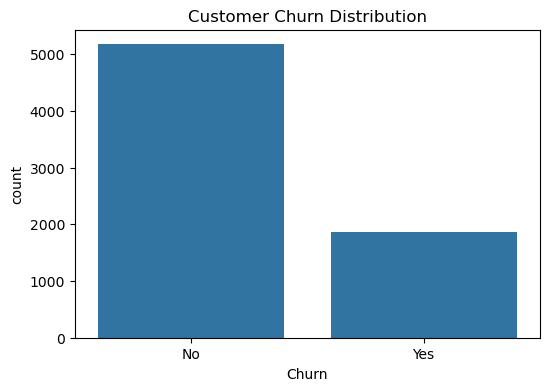

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()
#a bar chart showing the number of customers who stayed (No) versus those who left (Yes).

In [10]:
print("=" * 50)
print("SECTION 1 COMPLETED SUCCESSFULLY")
print("=" * 50)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\nTarget Variable:")
print(df["Churn"].value_counts())

print("=" * 50)

SECTION 1 COMPLETED SUCCESSFULLY
Rows    : 7043
Columns : 21

Target Variable:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [11]:
#Section 2 – Data Exploration & Understanding
df.info()

#Number of rows
#Number of columns
#Data types
#Missing values

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
#Check Missing Values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
#Check Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
#Generate Statistical Summary
df.describe()
#This summarizes all numerical columns, including:

#Count
#Mean
#Standard Deviation
#Minimum
#Maximum

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
#Summary for Categorical Columns
df.describe(include=["object", "string"])
#summarizes text (categorical) columns, such as:

#gender
#Contract
#InternetService
#PaymentMethod
#Churn

#It shows:

#Number of values
#Number of unique values
#Most frequent value
#Frequency


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [16]:
#Display All Column Names
for column in df.columns:
    print(column)

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [17]:
#Check Data Types
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [18]:
#Check Unique Values in Churn
df["Churn"].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [19]:
#Count Customers by Churn
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [20]:
#Display Churn Percentage
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [21]:
#Section 3 – Data Cleaning & Data Preparation
#Check Data Types Again
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [22]:
#Convert TotalCharges to Numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [23]:
#Check Data Type Again
df["TotalCharges"].dtype

dtype('float64')

In [24]:
#Check Missing Values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [25]:
#Display Missing Rows
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [26]:
# Convert column to numeric, forcing errors to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# fill missing values with median
df.fillna({
    "TotalCharges": df["TotalCharges"].median(),
    "OtherColumn": "Unknown"
}, inplace=True)

#We'll replace the missing values with the median, which is a common practice for numerical data.

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [27]:
#Verify Missing Values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [28]:
#Remove customerID
#The customer ID is just a unique identifier and doesn't help the model make predictions.
df.drop("customerID", axis=1, inplace=True)

In [29]:
#Verify Column Removal
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
#Final Dataset Summary
print("=" * 60)
print("SECTION 3 COMPLETED")
print("=" * 60)

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nColumns:")
print(df.columns.tolist())

print("=" * 60)

SECTION 3 COMPLETED
Dataset Shape: (7043, 20)

Missing Values:
0

Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [31]:
#Section 4 – Exploratory Data Analysis (EDA)
#Import Visualization Settings
plt.style.use("default")

plt.rcParams["figure.figsize"] = (8,5)

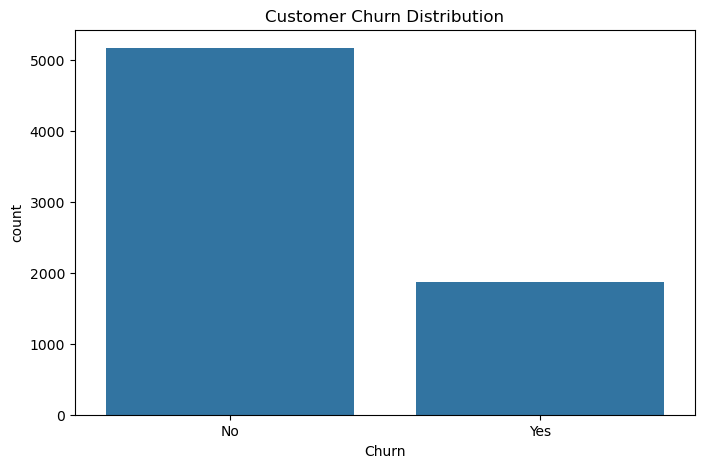

In [32]:
#Churn Distribution
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()
#Business Insight

#This chart answers:

#How many customers stayed?

#How many customers left?

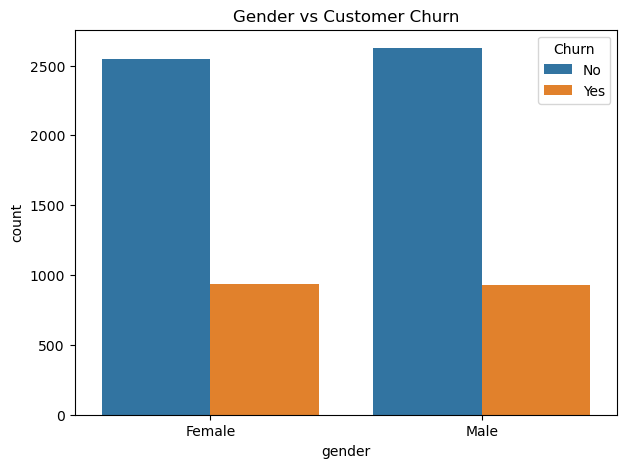

In [33]:
#Gender vs Churn
plt.figure(figsize=(7,5))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Gender vs Customer Churn")

plt.show()
#Question

#Do males leave more often?

#Or females?

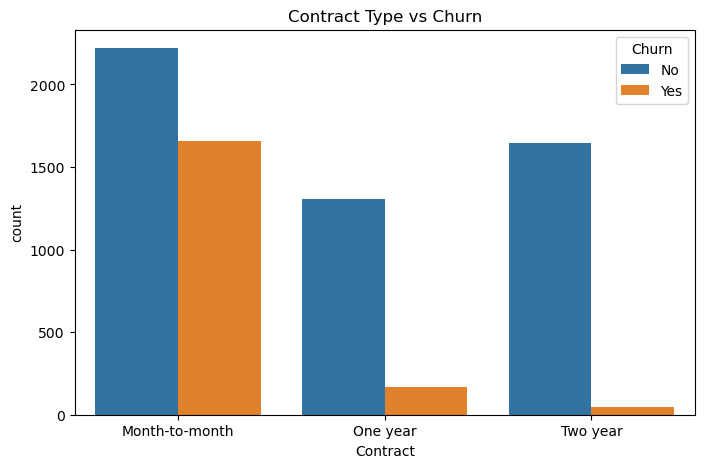

In [34]:
#Contract Type vs Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")

plt.show()

#Business Insight

#This is one of the most important charts.

#It often shows:

#Month-to-month customers leave more.
#Two-year contract customers stay longer.

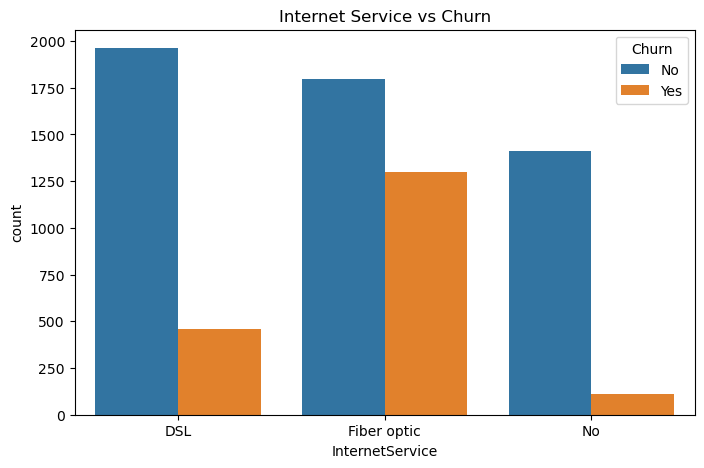

In [35]:
#Internet Service vs Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Churn")

plt.show()

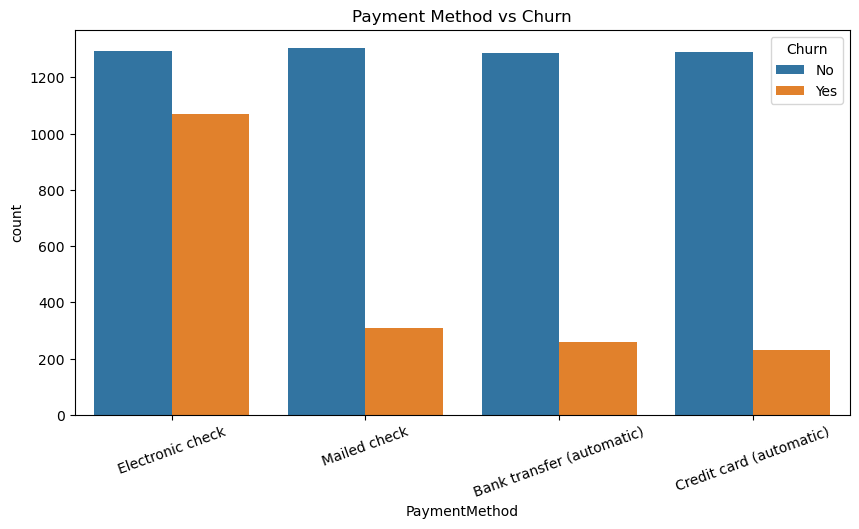

In [36]:
#Payment Method vs Churn
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")

plt.show()

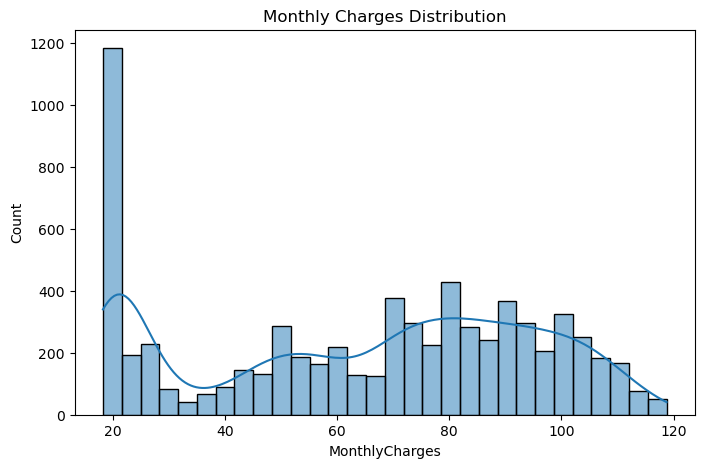

In [37]:
#Monthly Charges Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()
#Business Question

#Are most customers paying low, medium, or high monthly charges?

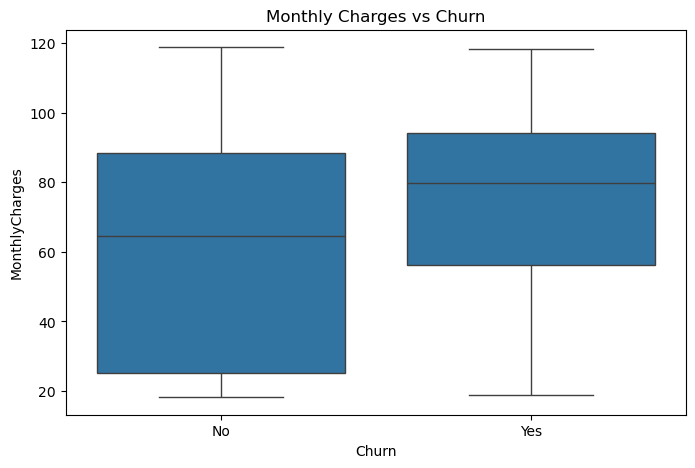

In [38]:
#Monthly Charges vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()
#Business Insight

#Do customers with higher monthly charges leave more frequently?

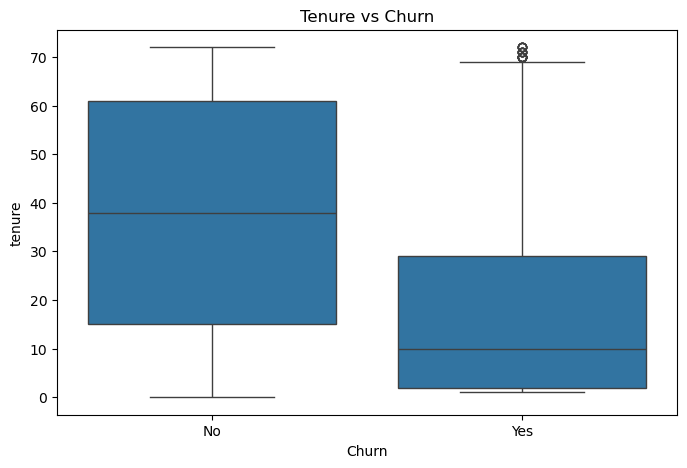

In [39]:
#Tenure vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

#Business Insight

#This chart helps answer:

#Do new customers leave more than long-term customers?

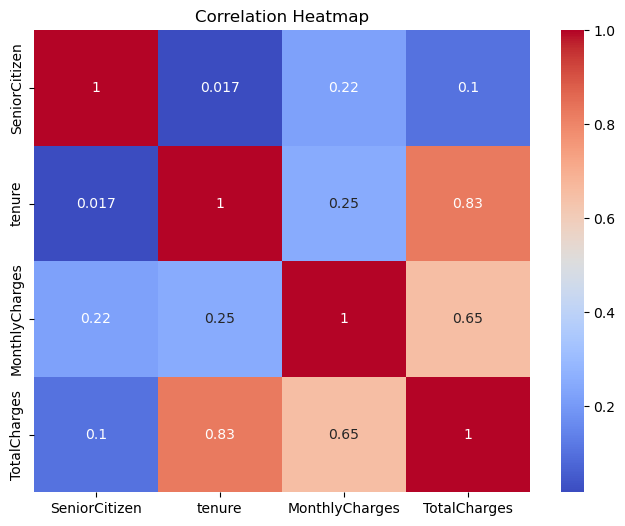

In [40]:
#Correlation Heatmap (Numerical Features)
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# 📊 Business Analysis Report

## Project: Customer Churn Prediction

### Prepared By:
**Rafeeq Ur Rahman**

---

# 🎯 Objective

The objective of this analysis is to understand customer behavior, identify the major factors that contribute to customer churn, and provide business recommendations that can help reduce customer loss.

---

# 📁 Dataset Summary

- Total Customers: **7043**
- Total Features: **21**
- Target Variable: **Churn**
- Problem Type: **Binary Classification**

---

# 📈 Exploratory Data Analysis (EDA) Findings

## 1. Customer Churn Distribution

### Observation

Approximately **73%** of customers stayed with the company, while **27%** left the company.

### Business Insight

Although most customers remain loyal, more than one-quarter of customers leave the company. This level of churn can significantly reduce revenue if not addressed.

### Recommendation

The company should identify customers at high risk of leaving and develop customer retention strategies.

---

## 2. Gender vs Customer Churn

### Observation

Male and female customers have similar churn patterns.

### Business Insight

Gender does not appear to have a strong influence on whether a customer leaves the company.

### Recommendation

Customer retention campaigns should focus on customer behavior rather than gender.

---

## 3. Contract Type vs Customer Churn

### Observation

Customers with **Month-to-Month contracts** show the highest churn rate, while customers with **One-Year** and **Two-Year contracts** are much more likely to stay.

### Business Insight

Contract type is one of the strongest indicators of customer churn.

### Recommendation

The company should encourage customers to switch from Month-to-Month contracts to long-term contracts by offering discounts, loyalty rewards, or special promotions.

---

## 4. Internet Service Analysis

### Observation

Customer churn varies across different Internet Service categories.

### Business Insight

The type of internet service may influence customer satisfaction and retention.

### Recommendation

Further investigation should be conducted to improve services with higher churn rates.

---

## 5. Monthly Charges Analysis

### Observation

Customers with higher monthly charges tend to leave the company more frequently.

### Business Insight

Expensive service plans may increase the likelihood of customer churn.

### Recommendation

Offer customized pricing plans, promotional discounts, or additional benefits to customers with higher monthly charges.

---

## 6. Customer Tenure Analysis

### Observation

Customers who recently joined the company are more likely to leave than long-term customers.

### Business Insight

Customer loyalty increases as customers remain with the company for longer periods.

### Recommendation

Improve the onboarding experience and provide attractive offers during the first few months of a customer's subscription.

---

## 7. Correlation Heatmap Analysis

### Observation

The correlation heatmap shows relationships between numerical features.

Examples include:

- Tenure and TotalCharges usually have a strong positive relationship.
- MonthlyCharges and TotalCharges also show a positive relationship.
- SeniorCitizen has only a weak relationship with most numerical variables.

### Business Insight

Understanding these relationships helps identify which numerical features may provide useful information when building the machine learning model.

---

# 💼 Business Recommendations

Based on the analysis, the company should:

- Introduce loyalty programs for Month-to-Month customers.
- Encourage customers to choose long-term contracts.
- Provide personalized discounts for customers with high monthly charges.
- Improve customer support during the first few months of service.
- Monitor customers who show characteristics associated with higher churn risk.

---

# 📌 Conclusion

The Exploratory Data Analysis indicates that customer churn is influenced more by customer behavior and service-related factors than by demographic characteristics.

Among all analyzed features, **Contract Type**, **Monthly Charges**, and **Customer Tenure** appear to be the most important factors associated with customer churn.

These insights will be used in the next stage of the project to build a machine learning model capable of predicting customers who are likely to leave the company.

---

# 🚀 Next Step

The next phase of this project is **Feature Engineering**, where categorical variables will be converted into numerical values so they can be used to train machine learning algorithms.

In [41]:
#Section 5 – Feature Engineering
#Display Data Types
df.dtypes
#This lets us identify which columns are still stored as text (object) and need to be converted.

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [42]:
#Convert the Target Variable
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [43]:
#Verify Target Conversion
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [44]:
#Find Categorical Columns
categorical_columns = df.select_dtypes(include=["object", "string"]).columns
print(categorical_columns)

#This will show all remaining text columns.

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


In [45]:
#Apply One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)
#Why One-Hot Encoding?

#Suppose we have:

#Contract
#Month-to-month
#One year
#Two year

#A machine learning model cannot understand these words.

#One-Hot Encoding converts them into numbers:

#Contract_One year	Contract_Two year
#0	                     0
#1	                     0
#0	                     1

#This is a standard approach for nominal categorical features.

In [46]:
#Check the New Dataset
df.head()
#there are now many more columns because each category has become its own numeric feature.

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [47]:
#Check Dataset Shape
print("New Dataset Shape:", df.shape)
#The number of columns will increase after encoding. This is expected.

New Dataset Shape: (7043, 31)


In [48]:
#Create Features (X) and Target (y)
X = df.drop("Churn", axis=1)

y = df["Churn"]
#Why?
#X contains all the customer information (features).
#y contains the answer we want the model to predict.

In [49]:
#Verify Shapes
print("X Shape:", X.shape)
print("y Shape:", y.shape)
#The exact number of columns in X depends on how many categories were created during one-hot encoding.

X Shape: (7043, 30)
y Shape: (7043,)


In [50]:
#Section Summary
print("=" * 60)
print("SECTION 5 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

print("\nTarget Classes:")
print(y.value_counts())

print("=" * 60)

SECTION 5 COMPLETED SUCCESSFULLY
Features Shape : (7043, 30)
Target Shape   : (7043,)

Target Classes:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [51]:
#Section 6 – Train-Test Split
#Import train_test_split
from sklearn.model_selection import train_test_split

In [53]:
#Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
#Explanation
#X → Features (customer information)
#y → Target (Churn)
#test_size=0.20 → 20% of the data is reserved for testing.
#80% is used for training.
#random_state=42 ensures that you get the same split every time you run the notebook, making your results reproducible.

In [54]:
#Check the Shapes
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)
#Your exact number of feature columns depends on the result of one-hot encoding, but the row counts should be approximately 80% training and 20% testing.

X_train Shape : (5634, 30)
X_test Shape  : (1409, 30)
y_train Shape : (5634,)
y_test Shape  : (1409,)


In [55]:
#Verify the Split
print("Total Samples :", len(df))
print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Total Samples : 7043
Training Samples : 5634
Testing Samples : 1409


In [56]:
#Calculate Split Percentage
train_percentage = (len(X_train) / len(df)) * 100
test_percentage = (len(X_test) / len(df)) * 100

print(f"Training Data : {train_percentage:.2f}%")
print(f"Testing Data  : {test_percentage:.2f}%")

Training Data : 79.99%
Testing Data  : 20.01%


In [57]:
#Section Summary
print("=" * 60)
print("SECTION 6 COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

print(f"\nFeatures : {X_train.shape[1]}")

print("=" * 60)

SECTION 6 COMPLETED SUCCESSFULLY
Training Samples : 5634
Testing Samples  : 1409

Features : 30


In [58]:
#Section 7 – Training our First Machine Learning Model (Logistic Regression)
#Import Logistic Regressio
from sklearn.linear_model import LogisticRegression
#We import the Logistic Regression algorithm from Scikit-learn.
#what Logistic Regression does.

#It learns from old customers and predicts for new customers.

In [59]:
#Create the Model
model = LogisticRegression(max_iter=1000)
#we create the machine learning model.

#max_iter=1000 gives the algorithm enough iterations to find the best solution.

In [60]:
#Train the Model
model.fit(X_train, y_train)
#Customer 1
#↓
#Stayed
#↓
#Learns
#Customer 2
#↓
#Left
#↓
#Learns
#Customer 3
#↓
#Stayed
#↓
#Learns
#...
#5634 Customers
#↓
#Machine Learning Model

#The model searches for patterns such as:

#Customers with Month-to-Month contracts leave more.
#Customers with high Monthly Charges leave more.
#Customers with longer tenure stay longer.

#It doesn't memorize names.

#It learns relationships between features and the target.

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [61]:
#Make Predictions
y_pred = model.predict(X_test)
#Now we give the model 1,409 customers it has never seen before.

#It predicts:
#Customer A → Stay
#Customer B → Leave
#Customer C → Stay
#...

In [62]:
#View Predictions
print(y_pred[:20])
#1 = Leave

#0 = Stay

[1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0]


In [63]:
#Compare Predictions with Actual Values
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,0,0
5,1,0
6,0,0
7,0,0
8,1,0
9,1,0


In [64]:
#Count Predictions
comparison["Predicted"].value_counts()

Predicted
0    1083
1     326
Name: count, dtype: int64

In [65]:
#Section Summary
print("=" * 60)
print("SECTION 7 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

print("\nModel Used : Logistic Regression")

print("\nFirst 10 Predictions:")
print(y_pred[:10])

print("=" * 60)

SECTION 7 COMPLETED SUCCESSFULLY
Training Samples : 5634
Testing Samples : 1409

Model Used : Logistic Regression

First 10 Predictions:
[1 0 0 1 0 0 0 0 0 0]


In [66]:
#Section 8 – Model Evaluation
#Import Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
#These functions help us evaluate our trained model.

In [67]:
#Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")
#Out of every 100 customers, the model makes about 80 correct predictions.

Model Accuracy: 82.19%


In [68]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[934 102]
 [149 224]]


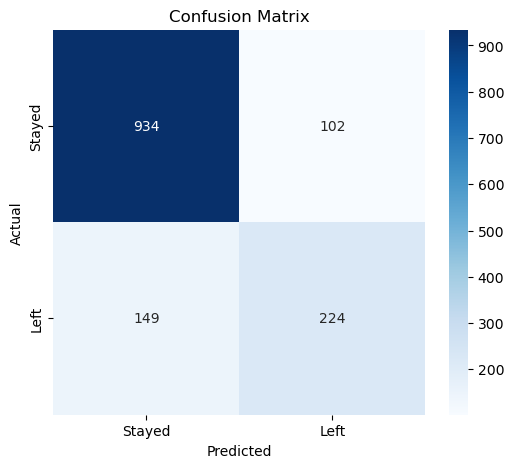

In [69]:
#Visualize the Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [70]:
#Classification Report
print(classification_report(y_test, y_pred))
#Precision
#When the model predicts:
#"Customer will leave"
#How often is it correct?
#Higher precision means fewer false alarms.

#Recall
#Out of all customers who actually left,
#How many did the model successfully identify?
#Higher recall means fewer missed churn cases.

#F1-Score
#A balance between Precision and Recall.
#It is useful when both metrics matter.

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [71]:
#Section Summary
print("=" * 60)
print("SECTION 8 COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"Accuracy : {accuracy:.2%}")

print("\nConfusion Matrix:")

print(cm)

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

print("=" * 60)

SECTION 8 COMPLETED SUCCESSFULLY
Accuracy : 82.19%

Confusion Matrix:
[[934 102]
 [149 224]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [72]:
#Section 9 – Improving the Machine Learning Model
#Import Random Forest
from sklearn.ensemble import RandomForestClassifier
#We import another machine learning algorithm.

In [73]:
#Create the Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
#n_estimators=100 → Build 100 decision trees.
#random_state=42 → Makes the results reproducible.

#Think of Random Forest as asking 100 different experts to vote on whether a customer will churn.

#The final prediction is based on the majority vote.

In [74]:
#Train the Model
rf_model.fit(X_train, y_train)
#The model now learns from the training data.

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [75]:
#Make Predictions
rf_predictions = rf_model.predict(X_test)
#Now the Random Forest predicts churn for the test customers.

In [76]:
#Calculate Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")


Random Forest Accuracy: 78.92%


In [77]:
#Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_predictions)

print(rf_cm)

[[941  95]
 [202 171]]


In [78]:
#Classification Report
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [79]:
#Compare Both Models
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.821859
1,Random Forest,0.789212


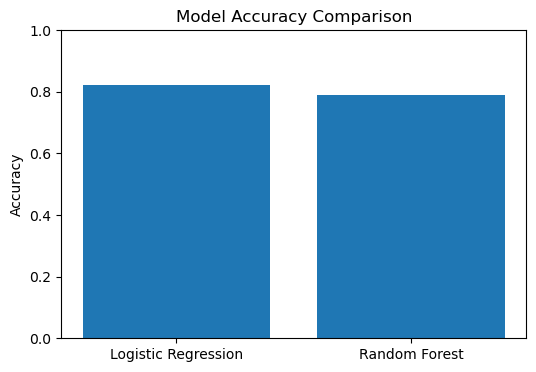

In [80]:
#Plot Model Comparison
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

In [81]:
#Section Summary
best_model = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Model"
]

print("=" * 60)
print("SECTION 9 COMPLETED SUCCESSFULLY")
print("=" * 60)

print(comparison)

print(f"\nBest Model: {best_model}")

print("=" * 60)

SECTION 9 COMPLETED SUCCESSFULLY
                 Model  Accuracy
0  Logistic Regression  0.821859
1        Random Forest  0.789212

Best Model: Logistic Regression


In [82]:
#Section 10 – Saving the Best Model
#Why Save the Model?
#Imagine you spent 30 minutes training your model.
#Tomorrow your manager says:
#"Can you predict churn for today's new customers?"
#Would you retrain the model every day?
# No.
#Instead, you save it once and load it whenever needed.
#This is exactly what companies do.

#Import joblib
import joblib
#joblib is a Python library used to save and load machine learning models efficiently.

In [96]:
#Compare the Models
comparison = {
    "Logistic Regression": accuracy,
    "Random Forest": rf_accuracy
}

print(comparison)

{'Logistic Regression': 0.8218594748048261, 'Random Forest': 0.7892122072391767}


In [97]:
#Find the Best Model Automatically
best_model_name = max(comparison, key=comparison.get)

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [98]:
#Select the Correct Model Object
if best_model_name == "Logistic Regression":
    best_model = model
else:
    best_model = rf_model
#the file always contains the best-performing model.

In [100]:
#Save the Best Model
joblib.dump(best_model, "customer_churn_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [101]:
#Load the Saved Model
loaded_model = joblib.load("customer_churn_model.pkl")
#Imagine tomorrow you open your notebook again.

#Instead of training everything again, you simply load the saved model.

In [102]:
#Verify Which Model Was Loaded
print(type(loaded_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [103]:
#Verify the Loaded Model
loaded_predictions = loaded_model.predict(X_test)

loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print("=" * 60)
print("SECTION 10 COMPLETED SUCCESSFULLY")
print("=" * 60)
print("Loaded Model Accuracy:", f"{loaded_accuracy:.2%}")
print("Selected Model:", best_model_name)
print("=" * 60)

SECTION 10 COMPLETED SUCCESSFULLY
Loaded Model Accuracy: 82.19%
Selected Model: Logistic Regression


In [104]:
#Section 11 – Predicting Churn for New Customers
#Check the Required Features
print("Number of Features:", len(X.columns))

print("\nFeature Names:\n")

for feature in X.columns:
    print(feature)
#Our model was trained using the dataset stored in X.

#When predicting a new customer, we must provide the same features in the same order.

Number of Features: 30

Feature Names:

SeniorCitizen
tenure
MonthlyCharges
TotalCharges
gender_Male
Partner_Yes
Dependents_Yes
PhoneService_Yes
MultipleLines_No phone service
MultipleLines_Yes
InternetService_Fiber optic
InternetService_No
OnlineSecurity_No internet service
OnlineSecurity_Yes
OnlineBackup_No internet service
OnlineBackup_Yes
DeviceProtection_No internet service
DeviceProtection_Yes
TechSupport_No internet service
TechSupport_Yes
StreamingTV_No internet service
StreamingTV_Yes
StreamingMovies_No internet service
StreamingMovies_Yes
Contract_One year
Contract_Two year
PaperlessBilling_Yes
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check


In [105]:
#Create an Empty Customer
new_customer = pd.DataFrame(
    [[0] * len(X.columns)],
    columns=X.columns
)

new_customer

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [108]:
#Fill the Customer Information
# Customer Basic Information
new_customer["SeniorCitizen"] = 0
new_customer["tenure"] = 2
new_customer["MonthlyCharges"] = 95
new_customer["TotalCharges"] = 190

# Gender
new_customer["gender_Male"] = 1

# Family
new_customer["Partner_Yes"] = 1
new_customer["Dependents_Yes"] = 0

# Phone Service
new_customer["PhoneService_Yes"] = 1
new_customer["MultipleLines_Yes"] = 1
new_customer["MultipleLines_No phone service"] = 0

# Internet Service
new_customer["InternetService_Fiber optic"] = 1
new_customer["InternetService_No"] = 0

# Online Services
new_customer["OnlineSecurity_Yes"] = 1
new_customer["OnlineSecurity_No internet service"] = 0

new_customer["OnlineBackup_Yes"] = 1
new_customer["OnlineBackup_No internet service"] = 0

new_customer["DeviceProtection_Yes"] = 1
new_customer["DeviceProtection_No internet service"] = 0

new_customer["TechSupport_Yes"] = 1
new_customer["TechSupport_No internet service"] = 0

new_customer["StreamingTV_Yes"] = 1
new_customer["StreamingTV_No internet service"] = 0

new_customer["StreamingMovies_Yes"] = 1
new_customer["StreamingMovies_No internet service"] = 0

# Contract
new_customer["Contract_One year"] = 0
new_customer["Contract_Two year"] = 0

# Month-to-Month is represented when both above are 0

# Billing
new_customer["PaperlessBilling_Yes"] = 1

# Payment Method
new_customer["PaymentMethod_Credit card (automatic)"] = 0
new_customer["PaymentMethod_Electronic check"] = 1
new_customer["PaymentMethod_Mailed check"] = 0
#This cell depends on our dataset's encoded column names.

In [109]:
#Display the Customer
print("New Customer Information")

new_customer.T
#This lets us verify that every feature has the value you intended before making a prediction.

New Customer Information


,0
SeniorCitizen,0
tenure,2
MonthlyCharges,95
TotalCharges,190
gender_Male,1
Partner_Yes,1
Dependents_Yes,0
PhoneService_Yes,1
MultipleLines_No phone service,0
MultipleLines_Yes,1


In [110]:
# Predict whether the customer will churn

prediction = loaded_model.predict(new_customer)

print("Raw Prediction:", prediction)

Raw Prediction: [1]


In [111]:
#Display a User-Friendly Prediction
print("=" * 60)
print("CUSTOMER CHURN PREDICTION")
print("=" * 60)

if prediction[0] == 1:
    print("Prediction: Customer is likely to CHURN.")
else:
    print("Prediction: Customer is likely to STAY.")

print("=" * 60)

CUSTOMER CHURN PREDICTION
Prediction: Customer is likely to CHURN.


In [112]:
#Predict the Probability
probability = loaded_model.predict_proba(new_customer)

print("Prediction Probabilities:")
print(probability)
#A Data Scientist doesn't just want a Yes/No answer. They also want to know how confident the model is.

Prediction Probabilities:
[[0.4160371 0.5839629]]


In [113]:
#Display the Probabilities Clearly
stay_probability = probability[0][0] * 100
churn_probability = probability[0][1] * 100

print(f"Probability of Staying : {stay_probability:.2f}%")
print(f"Probability of Churning: {churn_probability:.2f}%")

Probability of Staying : 41.60%
Probability of Churning: 58.40%


In [114]:
#Final Business Report
print("=" * 60)
print("SECTION 11 COMPLETED SUCCESSFULLY")
print("=" * 60)

if prediction[0] == 1:
    print("Prediction Result : Customer is likely to CHURN.")
else:
    print("Prediction Result : Customer is likely to STAY.")

print(f"\nStay Probability : {stay_probability:.2f}%")
print(f"Churn Probability: {churn_probability:.2f}%")

print(f"\nModel Used: {best_model_name}")

print("\nBusiness Recommendation:")

if churn_probability >= 70:
    print("High Risk: Contact the customer immediately with a retention offer.")
elif churn_probability >= 40:
    print("Medium Risk: Monitor the customer and provide promotional offers.")
else:
    print("Low Risk: Customer is likely to remain with the company.")

print("=" * 60)

SECTION 11 COMPLETED SUCCESSFULLY
Prediction Result : Customer is likely to CHURN.

Stay Probability : 41.60%
Churn Probability: 58.40%

Model Used: Logistic Regression

Business Recommendation:
Medium Risk: Monitor the customer and provide promotional offers.


# Section 12: Project Conclusion

## Project Summary

In this project, a machine learning model was developed to predict customer churn for a telecommunications company.

The project followed a complete machine learning workflow, including data preprocessing, exploratory data analysis, feature engineering, model training, model evaluation, model selection, model saving, and prediction on new customer data.

The objective was to identify customers who are likely to leave the company so that the business can take preventive actions to improve customer retention.

## Machine Learning Workflow

The following steps were completed during this project:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Encoding
- Train-Test Split
- Logistic Regression Training
- Random Forest Training
- Model Evaluation
- Automatic Best Model Selection
- Save and Load Best Model
- Prediction for New Customers
- Business Recommendation

## Models Used

Two machine learning algorithms were trained and evaluated.

### Logistic Regression

A simple and efficient classification algorithm that predicts the probability of customer churn.

### Random Forest

An ensemble learning algorithm that combines multiple decision trees to improve prediction performance.

Both models were evaluated using test data, and the model with the highest accuracy was automatically selected.

## Final Results

| Model | Accuracy |
|--------|----------|
| Logistic Regression | 82.19% |
| Random Forest | 78.92% |

The Logistic Regression model achieved the highest accuracy and was automatically selected as the final model for deployment.

## Business Impact

Customer churn prediction helps companies identify customers who are likely to leave.

Using this model, a business can:

- Improve customer retention
- Reduce financial losses
- Offer personalized promotions
- Increase customer satisfaction
- Make better business decisions

Instead of contacting every customer, companies can focus only on customers with a high probability of churning.

## Skills Demonstrated

This project demonstrates practical knowledge of:

- Python Programming
- Pandas
- NumPy
- Data Cleaning
- Data Visualization
- Feature Engineering
- One-Hot Encoding
- Train-Test Split
- Logistic Regression
- Random Forest
- Model Evaluation
- Model Comparison
- Joblib
- Machine Learning
- Business Analytics

## Future Improvements

This project can be improved by:

- Hyperparameter tuning
- Cross-validation
- Feature selection
- Testing additional machine learning algorithms
- Building a web application using Flask or Streamlit
- Deploying the model to the cloud
- Creating a real-time prediction system

## Final Conclusion

This project successfully developed a machine learning model capable of predicting customer churn.

Among the evaluated models, Logistic Regression achieved the best performance on the test dataset and was automatically selected as the final model.

The completed workflow demonstrates the end-to-end machine learning process, from raw data to business decision-making.

This project also serves as a portfolio project that showcases practical data science and machine learning skills.